In [3]:
# ===============================
# CELL 1: Library Imports
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


In [4]:
# ===============================
# CELL 2: Load Dataset
# ===============================

df = pd.read_csv("/content/drive/MyDrive/elephant_intrusion_forecasting_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (518, 13)


,date,day_of_week,month,season,rainfall_mm,temperature_c,humidity_percent,moon_phase,intrusion_last_3_days,intrusion_last_7_days,days_since_last_intrusion,grid_id,intrusion_next_day
0,2025-09-11,3,9,2,14.02,22.60,73.98,0.75,3,6,6,1,1
1,2025-08-04,0,8,2,12.18,24.47,75.89,0.35,3,7,3,3,1
2,2025-06-10,1,6,2,11.84,22.64,65.33,0.11,3,4,1,4,1
3,2025-08-29,4,8,2,11.88,23.55,73.00,0.30,2,6,1,2,1
4,2025-06-18,2,6,2,12.19,28.39,77.83,0.87,0,5,9,1,0


In [5]:
# ===============================
# CELL 3: Preprocessing
# ===============================

# Drop date (not needed for model)
df = df.drop(columns=["date"])

# Check missing values
print(df.isnull().sum())

# Features and Target
X = df.drop(columns=["intrusion_next_day"])
y = df["intrusion_next_day"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


day_of_week                  0
month                        0
season                       0
rainfall_mm                  0
temperature_c                0
humidity_percent             0
moon_phase                   0
intrusion_last_3_days        0
intrusion_last_7_days        0
days_since_last_intrusion    0
grid_id                      0
intrusion_next_day           0
dtype: int64
Train Shape: (414, 11)
Test Shape: (104, 11)


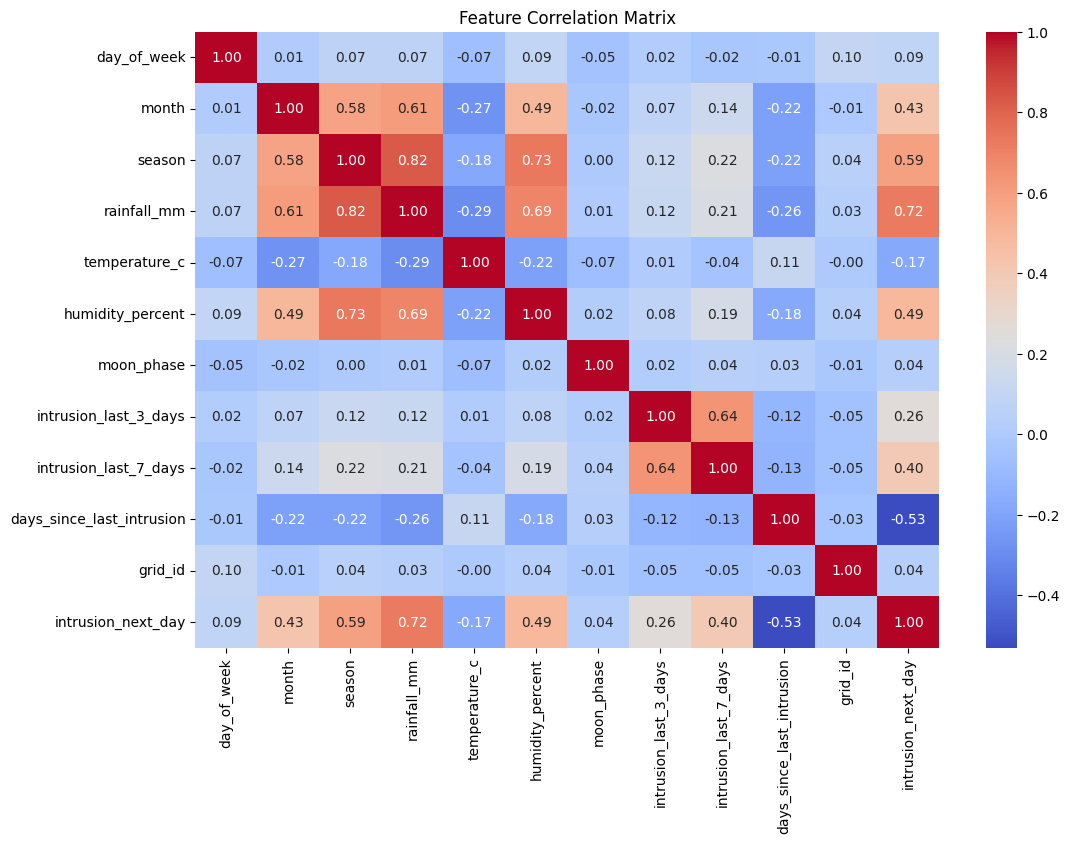

In [6]:
# ===============================
# CELL 4: Correlation Matrix
# ===============================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


In [7]:
# ===============================
# CELL 5: Scaling
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [8]:
# ===============================
# CELL 6: Model Definitions
# ===============================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200),
    "SVM": SVC(probability=True)
}


In [9]:
# ===============================
# CELL 7: Training & Evaluation
# ===============================

results = {}

for name, model in models.items():

    print(f"\n================ {name} ================")

    # Use scaled data for LR & SVM
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)

    results[name] = acc



================ Logistic Regression ================
Accuracy: 0.9903846153846154
Precision: 0.9811320754716981
Recall: 1.0
F1 Score: 0.9904761904761905
ROC-AUC: 1.0

================ Random Forest ================
Accuracy: 0.9615384615384616
Precision: 0.9444444444444444
Recall: 0.9807692307692307
F1 Score: 0.9622641509433962
ROC-AUC: 0.9970414201183432

================ Gradient Boosting ================
Accuracy: 0.9807692307692307
Precision: 0.9629629629629629
Recall: 1.0
F1 Score: 0.9811320754716981
ROC-AUC: 0.9966715976331361

================ SVM ================
Accuracy: 0.9807692307692307
Precision: 0.9629629629629629
Recall: 1.0
F1 Score: 0.9811320754716981
ROC-AUC: 0.9955621301775147


In [10]:
# ===============================
# CELL 8: Save Best Model
# ===============================

best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# Save best model
joblib.dump(best_model, "best_intrusion_model.pkl")

print("Model Saved Successfully!")



Best Model: Logistic Regression
Model Saved Successfully!


In [11]:
# ===============================
# CELL 9: Sample Web App Prediction
# ===============================

# Example input from web app
sample_input = pd.DataFrame([{
    "day_of_week": 4,
    "month": 2,
    "season": 0,
    "rainfall_mm": 12.5,
    "temperature_c": 27.3,
    "humidity_percent": 78,
    "moon_phase": 0.82,
    "intrusion_last_3_days": 2,
    "intrusion_last_7_days": 5,
    "days_since_last_intrusion": 1,
    "grid_id": 2
}])

# Load saved model
model = joblib.load("best_intrusion_model.pkl")
scaler = joblib.load("scaler.pkl")

if best_model_name in ["Logistic Regression", "SVM"]:
    sample_scaled = scaler.transform(sample_input)
    prob = model.predict_proba(sample_scaled)[0][1]
    pred = model.predict(sample_scaled)[0]
else:
    prob = model.predict_proba(sample_input)[0][1]
    pred = model.predict(sample_input)[0]

print("\nPrediction:", "Intrusion Likely" if pred==1 else "No Intrusion")
print("Probability:", round(prob*100,2), "%")



Prediction: Intrusion Likely
Probability: 90.73 %
